# Red Neuronal - Predicción de Supervivencia de Cirrosis

Modelo MLPClassifier con RandomizedSearchCV para predecir supervivencia de pacientes con cirrosis primaria biliar (PBC).

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib
import json
import os

#Cargar datos
df = pd.read_csv('cirrhosis.csv')

## 3. Transformar variables categóricas

In [2]:
# Crear copia para no modificar original
data = df.copy()

# Encoding de variables categóricas
# Sex: M=1, F=0
data['Sex'] = data['Sex'].map({'M': 1, 'F': 0})

# Drug: D-penicillamine=1, Placebo=0
data['Drug'] = data['Drug'].map({'D-penicillamine': 1, 'Placebo': 0})

# Variables binarias Y/N: Y=1, N=0
binary_vars = ['Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
for var in binary_vars:
    data[var] = data[var].map({'Y': 1, 'N': 0, 'S': 0.5})

# Status (target): D=1 (muerte), C/CL=0 (supervivencia/censored)
data['Status'] = data['Status'].map({'D': 1, 'C': 0, 'CL': 0})

## 4. Preparar features y target

In [3]:
# Seleccionar features (excluir ID, N_Days, Status)
# Usamos todas las columnas excepto ID, N_Days (administrativas) y Status (target)
feature_cols = [col for col in data.columns if col not in ['ID', 'N_Days', 'Status']]

X = data[feature_cols].copy()
y = data['Status'].copy()

## 5. Manejar valores faltantes

In [4]:
# Verificar si aún hay NaN
print(f"Valores NaN antes de drop: {X.isnull().sum().sum()}")

# Eliminar filas con valores faltantes
valid_idx = ~(X.isnull().any(axis=1) | y.isnull())
X = X[valid_idx]
y = y[valid_idx]

Valores NaN antes de drop: 1033


## 6. Train-Test Split

In [5]:
# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


## 7. Normalizar con StandardScaler

In [6]:
# Crear scaler
scaler = StandardScaler()

# Fit solo en train, transform en train y test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Entrenar modelo con RandomizedSearchCV

In [7]:

mlp = MLPClassifier(max_iter=10000)
param_grid = {
    "hidden_layer_sizes": [(8,), (16,), (32,), (64,)],
    "activation": ["relu", "tanh"],
    "alpha": [0.001, 0.01, 0.1],
}


# RandomizedSearchCV
grid_search = RandomizedSearchCV(
    mlp,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
)

# Entrenar
print("Entrenando modelo...")
grid_search.fit(X_train_scaled, y_train)

Entrenando modelo...


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier(max_iter=10000)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh'], 'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(8,), (16,), ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``c

## 9. Obtener mejor modelo

In [8]:
# Mejor modelo
best_model = grid_search.best_estimator_

grid_search.best_params_

# Hacer predicciones
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)

## 10. Calcular métricas

In [9]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = recall  # Same as recall

## 11. Visualizar Matriz de Confusión

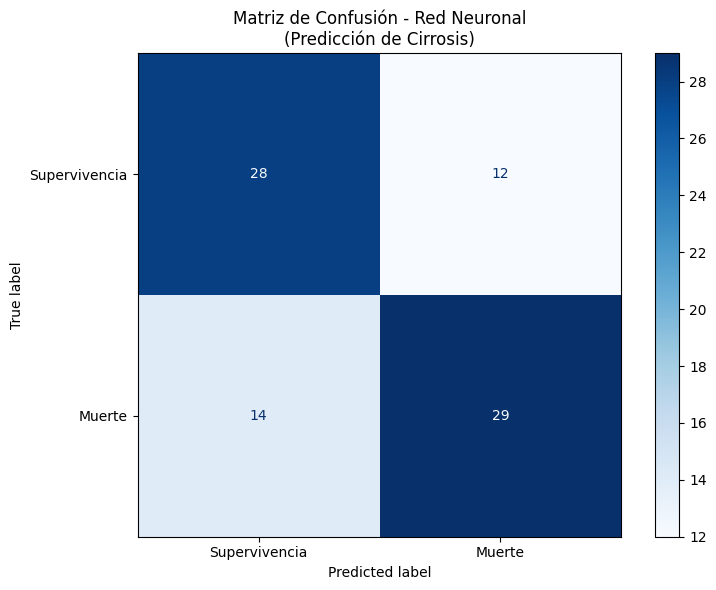

In [10]:
# Crear figura
fig, ax = plt.subplots(figsize=(8, 6))

# Plot confusion matrix
conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Supervivencia', 'Muerte'])
conf_matrix.plot(ax=ax, cmap='Blues')

plt.title('Matriz de Confusión - Red Neuronal\n(Predicción de Cirrosis)')
plt.tight_layout()
plt.show()

## 12. Guardar modelo, scaler y datos de prueba

In [11]:
# Directorio para guardar modelos
model_dir = '.'

# Guardar modelo
model_path = os.path.join(model_dir, 'cirrhosis_nn_model.pkl')
joblib.dump(best_model, model_path)
print(f"Modelo guardado: {model_path}")

# Guardar scaler
scaler_path = os.path.join(model_dir, 'cirrhosis_nn_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler guardado: {scaler_path}")

Modelo guardado: .\cirrhosis_nn_model.pkl
Scaler guardado: .\cirrhosis_nn_scaler.pkl


## 13. Guardar datos de prueba y métricas como JSON

In [12]:
# Preparar datos de prueba para batch prediction
test_data = {
    "X_test": X_test.values.tolist(),
    "y_test": y_test.values.tolist(),
    "y_pred": y_pred.tolist(),
    "feature_names": feature_cols
}

# Guardar test data
test_data_path = os.path.join(model_dir, 'cirrhosis_nn_test_data.json')
with open(test_data_path, 'w') as f:
    json.dump(test_data, f, indent=2)
print(f"Datos de prueba guardados: {test_data_path}")

# Preparar métricas
metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "confusion_matrix": {
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn)
    },
    "best_params": grid_search.best_params_,
    "best_cv_score": float(grid_search.best_score_)
}

# Guardar métricas
metrics_path = os.path.join(model_dir, 'cirrhosis_nn_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

Datos de prueba guardados: .\cirrhosis_nn_test_data.json
